## Revolut UK  Exploratory Data Analysis


#### Import libraries 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

Loading the cleaned dataset for analysis and visualization

In [2]:
df= pd.read_csv(r"C:\Users\computer1\Desktop\Revolut-Analysis\Data\revolut_cleaned.csv")
df

,transaction_id,user_id,transaction_date,transaction_time,transaction_type,transaction_category,amount,currency,transaction_status,payment_method,...,subscription_plan,fraud_flag,transaction_fee,revenue_generated,cashback_amount,year,month,month_name,day_of_week,hour
0,TXN007094,USR93203,2023-01-01,9:12:25,Transfer,Utilities,850.38,EUR,Successful,Card,...,Plus,0,8.50,6.80,4.25,2023,1,January,Sunday,9
1,TXN011155,USR17160,2023-01-01,13:45:55,Transfer,Shopping,4745.29,GBP,Successful,Bank Transfer,...,Standard,1,71.18,56.94,0.00,2023,1,January,Sunday,13
2,TXN002651,USR24022,2023-01-01,15:11:31,Purchase,Uncategorised,409.40,GBP,Successful,Apple Pay,...,Standard,0,6.14,4.91,0.00,2023,1,January,Sunday,15
3,TXN011642,USR85377,2023-01-01,21:01:06,Purchase,Food & Dining,643.73,EUR,Successful,Google Pay,...,Metal,0,1.29,1.03,9.66,2023,1,January,Sunday,21
4,TXN003802,USR80439,2023-01-01,22:24:18,Purchase,Shopping,143.16,GBP,Successful,Apple Pay,...,Metal,0,0.29,0.23,2.15,2023,1,January,Sunday,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,TXN001957,USR55745,2024-12-31,8:55:37,Top-up,Shopping,2021.10,GBP,Failed,Card,...,Plus,0,20.21,16.17,0.00,2024,12,December,Tuesday,8
14996,TXN007274,USR85454,2024-12-31,20:56:37,Purchase,Healthcare,418.49,EUR,Successful,Bank Transfer,...,Standard,0,6.28,5.02,0.00,2024,12,December,Tuesday,20
14997,TXN009711,USR55398,2024-12-31,22:09:14,Purchase,Shopping,630.43,GBP,Successful,Card,...,Standard,0,9.46,7.57,0.00,2024,12,December,Tuesday,22
14998,TXN014078,USR60014,2024-12-31,12:36:09,Transfer,Food & Dining,2544.17,USD,Successful,Card,...,Plus,0,25.44,20.35,12.72,2024,12,December,Tuesday,12


#### Convert  transaction date to date time

In [3]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
print(f"transaction_date dtype: {df['transaction_date'].dtype}")

transaction_date dtype: datetime64[ns]


## Exploratory Data Analysis

## 1. Transaction Status Distribution
Analysing the distribution of transaction statuses 
to understand overall platform performance and 
success rates.

In [4]:
status_counts = df['transaction_status'].value_counts()
status_pct = df['transaction_status'].value_counts(normalize=True) * 100

print("Transaction Status Breakdown:")
for status, count in status_counts.items():
 print(f"  {status}: {count:,} ({status_pct[status]:.1f}%)")

Transaction Status Breakdown:
  Successful: 12,774 (85.2%)
  Failed: 1,493 (10.0%)
  Reversed: 733 (4.9%)


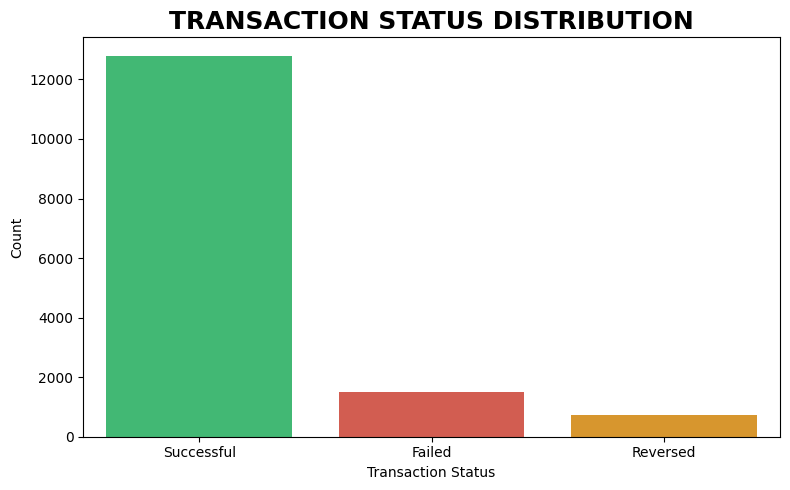

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='transaction_status', 
 hue='transaction_status',
 palette=['#2ecc71', '#e74c3c', '#f39c12'],
 legend=False)
plt.title('TRANSACTION STATUS DISTRIBUTION', 
  fontsize=18, fontweight='bold')
plt.xlabel('Transaction Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#### Observations
- 85.2% of transactions were successful showing strong 
  platform reliability
- 10% failure rate warrants further investigation 
  by payment method and country
- 4.9% reversal rate is within acceptable range 
  for a fintech platform


## 2. Revenue by Subscription Plan
Analysing total revenue generated across subscription 
plans to identify the most valuable customer segments.

In [6]:
revenue_by_plan = df.groupby('subscription_plan')['revenue_generated'].sum().sort_values(ascending=False)
revenue_pct = (revenue_by_plan / revenue_by_plan.sum()) * 100

print("Revenue by Subscription Plan:")
for plan, revenue in revenue_by_plan.items():
    print(f"  {plan}: £{revenue:,.2f} ({revenue_pct[plan]:.1f}%)")

Revenue by Subscription Plan:
  Standard: £84,261.32 (64.0%)
  Plus: £31,954.00 (24.3%)
  Premium: £11,528.33 (8.8%)
  Metal: £3,915.19 (3.0%)


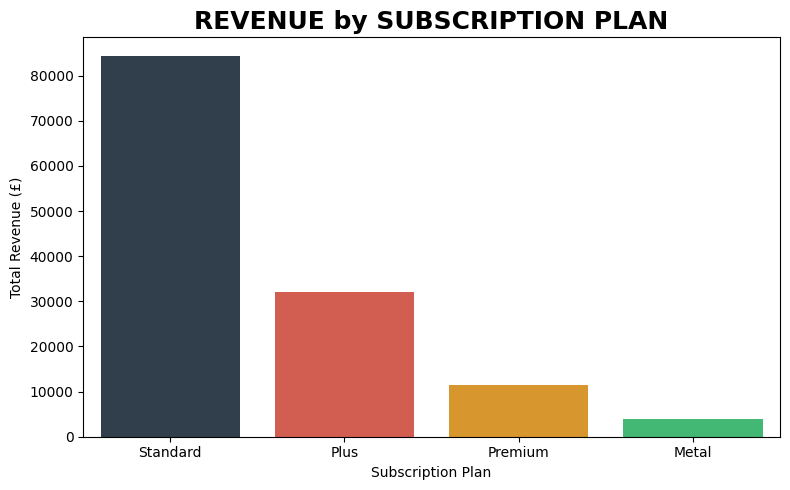

In [7]:
plt.figure(figsize=(8, 5))
sns.barplot(x=revenue_by_plan.index, 
  y=revenue_by_plan.values,
  hue=revenue_by_plan.index,
  palette=['#2c3e50', '#e74c3c', '#f39c12', '#2ecc71'],
 legend=False)
plt.title('REVENUE by SUBSCRIPTION PLAN', 
  fontsize=18, fontweight='bold')
plt.xlabel('Subscription Plan')
plt.ylabel('Total Revenue (£)')
plt.tight_layout()
plt.show()

#### Observations
- Standard plan generates the most revenue at 
  64% — driven by the highest number of subscribers
- Plus plan contributes 24.3% — a significant 
  middle tier that balances subscriber volume 
  with moderate fees
- Premium plan accounts for 8.8% — fewer subscribers 
  but higher value per transaction
- Metal plan contributes only 3% despite having 
  the highest fees — indicating very low subscriber 
  numbers
- Revolut should focus on upselling Standard users 
  to Plus and Premium plans to increase revenue 
  per customer without needing more subscribers

## 3. Transaction volume by month
Analysing monthly transaction trends to identify 
seasonal patterns and peak periods across 2023-2024.

In [14]:
monthly_volume = df.groupby(['year', 'month_name'])['transaction_id'].count()
print(monthly_volume)

year  month_name
2023  April         596
      August        596
      December      635
      February      542
      January       606
      July          623
      June          649
      March         643
      May           653
      November      679
      October       605
      September     616
2024  April         616
      August        644
      December      609
      February      590
      January       630
      July          665
      June          629
      March         629
      May           629
      November      601
      October       662
      September     653
Name: transaction_id, dtype: int64


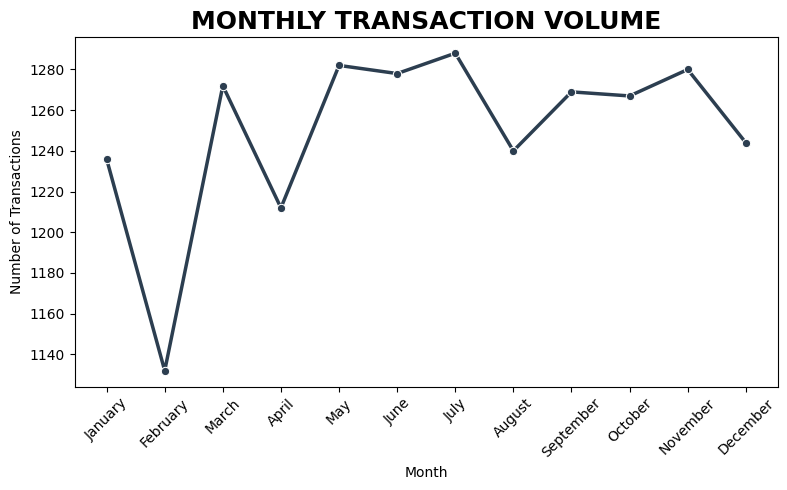

In [12]:
month_order = ['January','February','March','April',
   'May','June','July','August',
    'September','October','November','December']

monthly = df.groupby('month_name')['transaction_id'].count()
monthly = monthly.reindex(month_order)

plt.figure(figsize=(8, 5))
sns.lineplot(x=monthly.index, y=monthly.values, 
 color='#2c3e50', linewidth=2.5, marker='o')
plt.title('MONTHLY TRANSACTION VOLUME', 
 fontsize=18, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Observations
- Transaction volumes are relatively consistent 
  month to month — no dramatic seasonal spikes
- November 2023 saw the highest activity possibly 
  driven by Black Friday and holiday spending
- December shows a slight dip likely due to 
  reduced business activity over Christmas
- Overall volume is stable across both years 
  suggesting steady platform growth

## 4. Fraud Analysis by Transaction Category
Identifying which transaction categories have the 
highest concentration of fraudulent activity

In [10]:
fraud_by_category = df[df['fraud_flag'] == 1]['transaction_category'].value_counts()
fraud_pct = (fraud_by_category / df['transaction_category'].value_counts()) * 100

print("Fraud by Transaction Category:")
for category, count in fraud_by_category.items():
   print(f"  {category}: {count} fraudulent transactions ({fraud_pct[category]:.1f}% of category)")

Fraud by Transaction Category:
  Food & Dining: 135 fraudulent transactions (4.1% of category)
  Shopping: 128 fraudulent transactions (4.3% of category)
  Travel: 78 fraudulent transactions (3.6% of category)
  Utilities: 74 fraudulent transactions (4.2% of category)
  Entertainment: 56 fraudulent transactions (3.8% of category)
  Healthcare: 41 fraudulent transactions (3.5% of category)
  Transfer: 41 fraudulent transactions (3.5% of category)
  Other: 29 fraudulent transactions (3.9% of category)
  Uncategorised: 5 fraudulent transactions (2.2% of category)


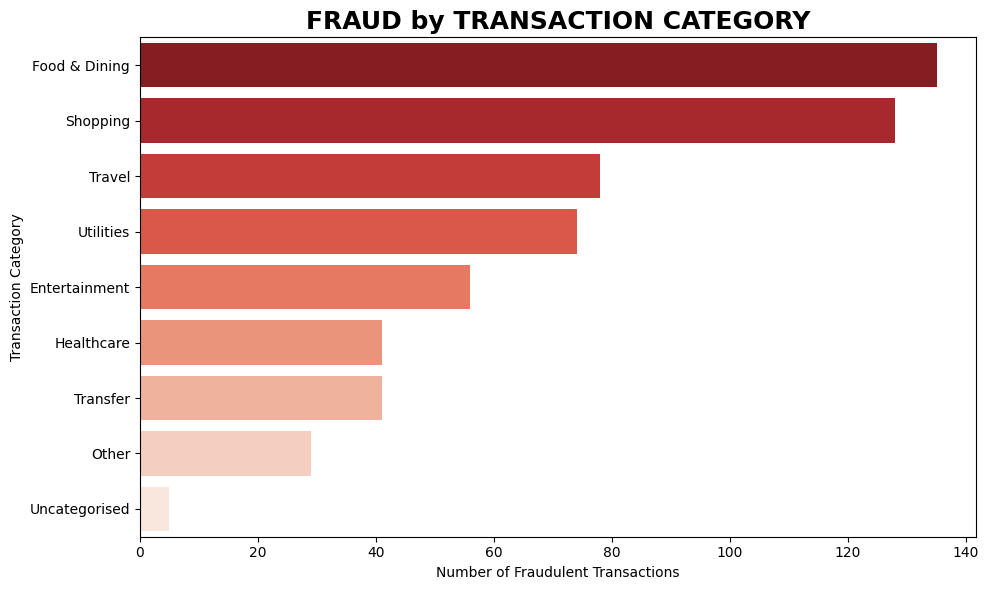

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(x=fraud_by_category.values,
 y=fraud_by_category.index,
 hue=fraud_by_category.index,
 palette='Reds_r',
 legend=False)
plt.title('FRAUD by TRANSACTION CATEGORY',
 fontsize=18, fontweight='bold')
plt.xlabel('Number of Fraudulent Transactions')
plt.ylabel('Transaction Category')
plt.tight_layout()
plt.show()

#### Observations
- Food & Dining and Shopping categories have the 
  highest fraud counts combining for nearly 50% 
  of all fraudulent transactions
- Fraud rate is fairly consistent across categories 
  at 3.5% to 4.3% suggesting no single category 
  is disproportionately targeted
- Enhanced monitoring on Food & Dining and Shopping 
  transactions could significantly reduce overall fraud

## 5. Transaction Amount Distribution
Analysing the distribution of transaction amounts 
to understand customer spending behaviour and 
identify high value transaction patterns.

In [15]:
print("Transaction Amount Summary:")
print(f"  Mean:   £{df['amount'].mean():,.2f}")
print(f"  Median: £{df['amount'].median():,.2f}")
print(f"  Min:    £{df['amount'].min():,.2f}")
print(f"  Max:    £{df['amount'].max():,.2f}")
print(f"\nAmount brackets:")
bins = [0, 100, 500, 1000, 2000, 10000]
labels = ['£0-100', '£101-500', '£501-1000', '£1001-2000', '£2000+']
df['amount_bracket'] = pd.cut(df['amount'], bins=bins, labels=labels)
print(df['amount_bracket'].value_counts().sort_index())

Transaction Amount Summary:
  Mean:   £1,089.68
  Median: £607.14
  Min:    £2.05
  Max:    £9,965.14

Amount brackets:
amount_bracket
£0-100        1155
£101-500      5086
£501-1000     4456
£1001-2000    2060
£2000+        2243
Name: count, dtype: int64


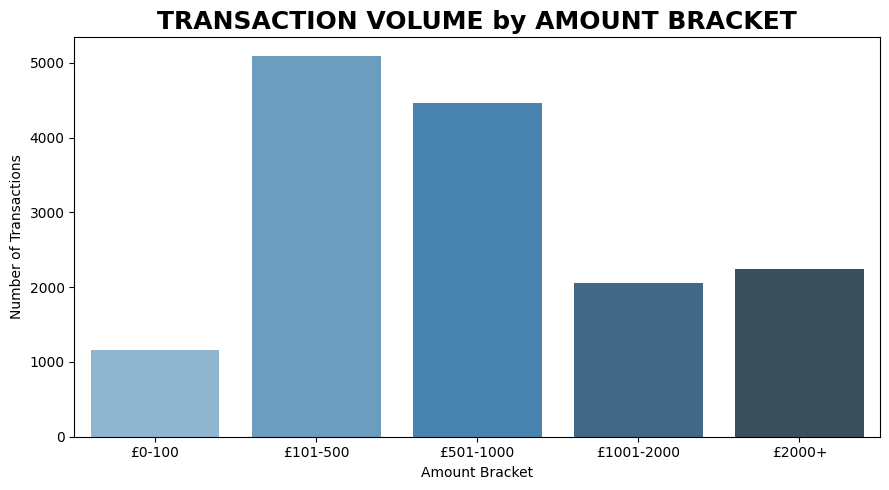

In [18]:
plt.figure(figsize=(9, 5))
bracket_counts = df['amount_bracket'].value_counts().sort_index()
sns.barplot(x=bracket_counts.index,
            y=bracket_counts.values,
            hue=bracket_counts.index,
            palette='Blues_d',
            legend=False)
plt.title('TRANSACTION VOLUME by AMOUNT BRACKET',
          fontsize=18, fontweight='bold')
plt.xlabel('Amount Bracket')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

#### Observations
- £101-500 is the most common spending bracket 
  accounting for 34% of all transactions
- A significant 15% of transactions exceed £2,000 
  indicating a healthy high value customer segment
- Very few micro transactions under £100 suggesting 
  Revolut users primarily use the platform for 
  mid to high value payments
- Mean (£1,089) is significantly higher than median 
  (£607) confirming high value outliers pulling 
  the average up